
# 3D Frequency Domain Plot

## Original Code
Demonstrates using ax.plot's *zdir* keyword to plot 2D data on
selective axes of a 3D plot.


<Figure size 1000x600 with 0 Axes>

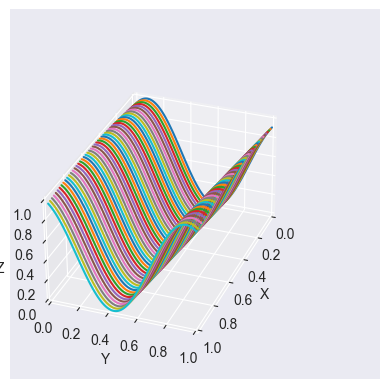

In [2]:
from mpl_toolkits.mplot3d.axes3d import Axes3D
from mpl_toolkits.mplot3d import proj3d

import matplotlib.pyplot as plt
import numpy as np
import os

# 
fig = plt.figure(figsize=(10, 6))  # Increase width (12) relative to height (6)
ax = plt.figure().add_subplot(projection='3d')

"""                                                                                                                                                    
Scaling is done from here...                                                                                                                           
"""
x_scale=3
y_scale=2
z_scale=2

scale=np.diag([x_scale, y_scale, z_scale, 1.0])
scale=scale*(1.0/scale.max())
scale[3,3]=1.0

def short_proj():
  return np.dot(Axes3D.get_proj(ax), scale)

ax.get_proj=short_proj
"""                                                                                                                                                    
to here                                                                                                                                                
"""

# Plot a sin curve using the x and y axes.
x = np.linspace(0, 1, 100)
ns = np.linspace(0, 1, 50)

for n in ns:
    y = np.sin(x * 2 * np.pi+(n+1)) / 2 + 0.5
    ax.plot(x, y, zs=n, zdir='x', label=f'{n} curve in (x, y)')

# Plot scatterplot data (20 2D points per colour) on the x and z axes.
colors = ('r', 'g', 'b', 'k')

# Fixing random state for reproducibility
np.random.seed(19680801)

x = np.random.sample(20 * len(colors))
y = np.random.sample(20 * len(colors))
c_list = []
for c in colors:
    c_list.extend([c] * 20)
# By using zdir='y', the y value of these points is fixed to the zs value 0
# and the (x, y) points are plotted on the x and z axes.
#ax.scatter(x, y, zs=0, zdir='z', c=c_list, label='points in (x, z)')

# Make legend, set axes limits and labels
#ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_zlim(0, 1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Customize the view angle so it's easier to see that the scatter points lie
# on the plane y=0
ax.view_init(elev=30, azim=20, roll=0)

plt.show()

.. tags::
   plot-type: 3D, plot-type: scatter, plot-type: line,
   component: axes,
   level: intermediate

## Some data manipulation

In [47]:
from vna.VNA_utils import open_pickled_object_in_pickle_folder, pickle_object, convert_magnitude_cols_to_db

# results_df = open_pickled_object_in_pickle_folder('glove_experiment_results_correct.pkl')
# results_df = results_df.loc[:, ~results_df.columns.duplicated()]
# results_without_repeat = results_df[~results_df['id'].str.contains('same_gesture')]
# results_just_repeat = results_df[results_df['id'].str.contains('same_gesture')]
# results_without_repeat = convert_magnitude_cols_to_db(results_without_repeat)


results_without_repeat['s_parameter'][0]

'S11'

In [5]:
%load_ext timeit
import sys
'IPython' in sys.modules

The timeit module is not an IPython extension.


True

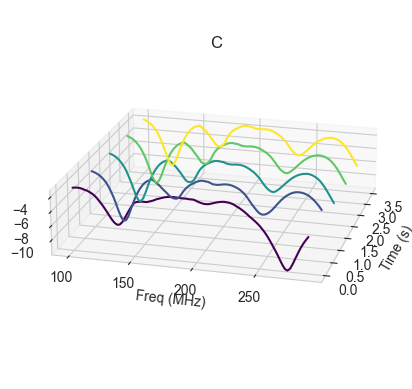

In [13]:
import pandas as pd
import random
from vna.VNA_utils import open_pickled_object_in_pickle_folder, pickle_object, convert_magnitude_cols_to_db
import seaborn as sns
from matplotlib import cm
from matplotlib import colors
from vna.VNA_utils import hz_to_mhz
import matplotlib.ticker as ticker
import numpy as np
import matplotlib.pyplot as plt


results_without_repeat = open_pickled_object_in_pickle_folder('glove_experiment_singles_only.pkl')
results_without_repeat = convert_magnitude_cols_to_db(results_without_repeat)
experiments = results_without_repeat['label'].unique()
s_param = 'S11'
mag_or_phase = 'magnitude'

output_df = None
for experiment in experiments:
    # get all the same label experiments -> this means the same gesture 
    same_gesture = results_without_repeat[(results_without_repeat['label'] == experiment) & (results_without_repeat['s_parameter'] == s_param) & (results_without_repeat['mag_or_phase'] == mag_or_phase)]
    
    single_gesture = same_gesture[same_gesture['id'] == random.choice(same_gesture['id'].unique())]
    # output will contain one unique gesture capture for each 
    output_df = pd.concat([output_df, single_gesture], ignore_index=True)



single_gesture_df = output_df[output_df['label'] == random.choice(output_df['label'].unique())]
single_gesture_df = single_gesture_df.reset_index(drop=True)
chosen_gesture = single_gesture_df['label'][0].split('_')[-1]
stop_index = 100

single_gesture_df = single_gesture_df[single_gesture_df['time'] < single_gesture_df['time'].max() * 0.6]

group = single_gesture_df.iloc[:,4:stop_index].groupby('time')

# plt.figure(dpi=250)
sns.set_style('whitegrid')
frequency_cols = list(map(hz_to_mhz, list(single_gesture_df.columns[5:stop_index])))

#this is iterated over to place the lines in the 3rd D
plotting_indexes = np.linspace(0, single_gesture_df['time'].max(), len(group))
time = single_gesture_df['time']
times_normalized = time - time.min()

ax = plt.figure().add_subplot(projection='3d')


norm = colors.Normalize(vmin=min(plotting_indexes), vmax=max(plotting_indexes))
cmap = cm.viridis  # Choose a colormap (you can try 'plasma', 'inferno', etc.)

i=0
for plotting_index, (group_name, df) in zip(plotting_indexes, group):

    y = df.iloc[:,1:].values[0]
    
    # y.apply(lambda val:val-list(y)[0])
    color = cmap(norm(plotting_index))
    ax.plot(frequency_cols, y, zs=plotting_index, color=color, zdir='x', label=f'{group_name}s')
    
# scatter = ax.scatter(frequency_cols, y, plotting_indexes, c=plotting_indexes, cmap='viridis', s=50)

# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1)
# ax.set_zlim(0, 1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Freq (MHz)')
ax.set_zlabel('|dB|')
ax.set_title(chosen_gesture, y=0.95)
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))


ax.invert_xaxis()
# Customize the view angle so it's easier to see that the scatter points lie
# on the plane y=0
ax.view_init(elev=20, azim=15, roll=0)
ax.set_box_aspect([4, 4, 1])

plt.show()


In [65]:
single_gesture_df = single_gesture_df.reset_index(drop=True)
single_gesture_df['label'][0].split('_')[-1]

'B'

In [7]:
 """                                                                                                                                                    
Scaling
 is done from here...                                                                                                                           
"""
x_scale = 3
y_scale = 2
z_scale = 1

scale = np.diag([x_scale, y_scale, z_scale, 1.0])
scale = scale * (1.0 / scale.max())
scale[3, 3] = 1.0


def short_proj():
    return np.dot(Axes3D.get_proj(ax), scale)


ax.get_proj = short_proj
"""                                                                                                                                                    
to here                                                                                                                                                
"""

'                                                                                                                                                    \nto here                                                                                                                                                \n'

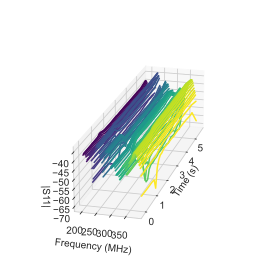

In [10]:
import seaborn as sns
from matplotlib import cm
from matplotlib import colors
from vna.VNA_utils import hz_to_mhz
import matplotlib.ticker as ticker

sns.set_style('whitegrid')
frequency_cols = list(single_gesture_df.columns[50:150])

#this is iterated over to place the lines in the 3rd D
plotting_indexes = np.linspace(0, 1, len(frequency_cols))
time = single_gesture_df['time']
times_normalized = (time - time.min()) / (time.max() - time.min())

ax = plt.figure().add_subplot(projection='3d')


norm = colors.Normalize(vmin=min(plotting_indexes), vmax=max(plotting_indexes))
cmap = cm.viridis  # Choose a colormap (you can try 'plasma', 'inferno', etc.)

i=0
for plotting_index, frequency_col in zip(plotting_indexes, frequency_cols):
    if i%1 == 0:
        y = single_gesture_df[frequency_col]
        
        # y.apply(lambda val:val-list(y)[0])
        color = cmap(norm(plotting_index))
        ax.plot(time, y, zs=hz_to_mhz(frequency_col), color=color, zdir='y', label=f'{frequency_col}Hz')
    i+=1
# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1)
# ax.set_zlim(0, 1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (MHz)')
ax.set_zlabel('|S11|')
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))


ax.invert_xaxis()
# Customize the view angle so it's easier to see that the scatter points lie
# on the plane y=0
ax.view_init(elev=20, azim=15, roll=0)
ax.set_box_aspect([4, 1, 1])
plt.show()

KeyboardInterrupt: 

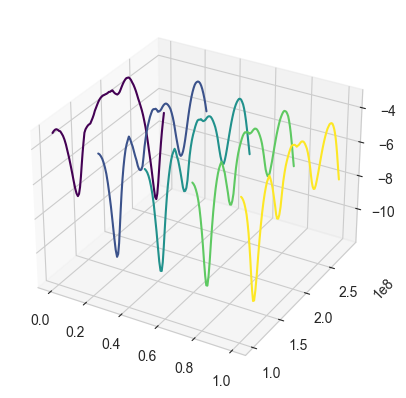

In [14]:
import seaborn as sns
from matplotlib import cm
from matplotlib import colors
from vna.VNA_utils import hz_to_mhz
import matplotlib.ticker as ticker
import numpy as np
import matplotlib.pyplot as plt

stop_index = 100

group = single_gesture_df.iloc[:,4:stop_index].groupby('time')

sns.set_style('whitegrid')
frequency_cols = list(single_gesture_df.columns[5:stop_index])

#this is iterated over to place the lines in the 3rd D
plotting_indexes = np.linspace(0, 1, len(group))
time = single_gesture_df['time']
times_normalized = (time - time.min()) / (time.max() - time.min())

ax = plt.figure().add_subplot(projection='3d')


norm = colors.Normalize(vmin=min(plotting_indexes), vmax=max(plotting_indexes))
cmap = cm.viridis  # Choose a colormap (you can try 'plasma', 'inferno', etc.)

i=0
for plotting_index, (group_name, df) in zip(plotting_indexes, group):

    y = df.iloc[:,1:].values[0]
    
    # y.apply(lambda val:val-list(y)[0])
    color = cmap(norm(plotting_index))
    ax.plot(frequency_cols, y, zs=plotting_index, color=color, zdir='x', label=f'{group_name}s')

# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1)
# ax.set_zlim(0, 1)
ax.set_xlabel('Time')
ax.set_ylabel('Freq')
ax.set_zlabel('|dB|')
ax.set_title('Test')
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))


ax.invert_xaxis()
# Customize the view angle so it's easier to see that the scatter points lie
# on the plane y=0
ax.view_init(elev=20, azim=15, roll=0)
ax.set_box_aspect([4, 3, 1])
plt.tight_layout()
plt.show()

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib import colors, cm
import matplotlib.ticker as ticker

# Assuming single_gesture_df is already defined and contains the necessary data
# Let's set the style and define the frequency columns
sns.set_style('whitegrid')
frequency_cols = list(single_gesture_df.columns[60:100])  # Adjust column range as needed


AttributeError: 'float' object has no attribute 'min'

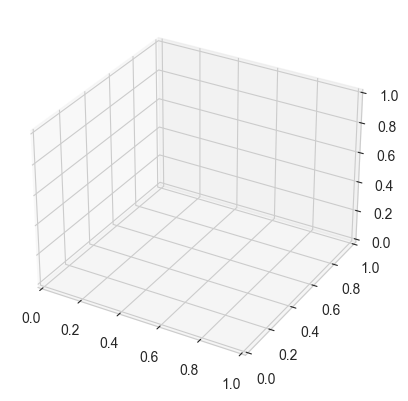

In [10]:



# Normalizing the time values between 0 and 1 for colormap mapping
time = single_gesture_df['time']
#time_normalized = (time - time.min()) / (time.max() - time.min())  # Normalize time

# Set up the plot
ax = plt.figure().add_subplot(projection='3d')

# Choose a colormap (e.g., 'viridis', 'plasma', 'inferno')
cmap = cm.plasma  
norm = colors.Normalize(vmin=time_normalized.min(), vmax=time_normalized.max())  # Normalize based on time


# Loop through the frequency columns and plot each frequency trace
for frequency_col in frequency_cols:
    y = single_gesture_df[frequency_col]
    
    # Iterate over pairs of consecutive points to plot line segments with color based on time
    for i in range(len(time) - 1):
        # Segment data
        time_segment = time.iloc[i:i+2]
        y_segment = y.iloc[i:i+2]
        
        # Normalize the current time (for color mapping)
        segment_time_norm = (time_segment - time.min()) / (time.max() - time.min())
        
        # Use the midpoint time of the segment for coloring
        color = cmap(norm(segment_time_norm.mean()))
        
        # Plot the line segment with the appropriate color
        ax.plot(time_segment, y_segment, zs=hz_to_mhz(frequency_col), color=color, zdir='y')

# Set axis labels
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (MHz)')
ax.set_zlabel('|S11|')

# Reduce the number of y-axis ticks (set max 5 ticks)
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))

# Invert x-axis if needed
ax.invert_xaxis()

# Customize the view angle for better visualization
ax.view_init(elev=20, azim=15, roll=0)

# Show the plot
plt.show()

In [51]:
from sklearn.preprocessing import MinMaxScaler

values = single_gesture_df[260000000].values
values = values.reshape(len(values),1)
scaler = MinMaxScaler(feature_range=(0,1))
scaler.fit(values)

print(
      f"{scaler.data_min_} {scaler.data_max_}")

normalized_values = scaler.transform(values)

# single_gesture_df.columns = single_gesture_df.columns.astype(str)
scaler.fit_transform(single_gesture_df[list(single_gesture_df.columns[5:])])



[-41.7632022] [-35.017882]


array([[0.98204495, 0.9755124 , 0.98353228, ..., 0.92549499, 0.88894032,
        0.85527866],
       [0.98204495, 0.9755124 , 0.98353228, ..., 0.92549499, 0.88894032,
        0.85527866],
       [0.98411461, 0.9783011 , 0.99000698, ..., 0.91807377, 0.89296486,
        0.85053688],
       ...,
       [0.01020527, 0.03529899, 0.        , ..., 0.18483247, 0.17888903,
        0.15380732],
       [0.00397205, 0.01129053, 0.01207827, ..., 0.1872996 , 0.16783027,
        0.11448394],
       [0.00241164, 0.0242079 , 0.05331423, ..., 0.17240287, 0.1655639 ,
        0.13269042]])

In [50]:
# results_without_repeat[results_without_repeat['id'] == results_without_repeat['id'].unique()[0]]


def normalise_group(grouped_df, feature_range=(0,1)):
    fq_cols = grouped_df.iloc[:,5:]
    scalar = MinMaxScaler(feature_range=feature_range)
    scaled_values = scalar.fit_transform(fq_cols)
    scaled_df = pd.DataFrame(scaled_values, columns=fq_cols.columns, index=fq_cols.index)
    # Replace the original columns with normalized values
    grouped_df.iloc[:, 5:] = scaled_df
    return grouped_df
        

# result = (results_without_repeat.groupby('id', group_keys=False)
#           .apply(lambda id_group: 
#                            id_group.groupby('mag_or_phase', group_keys=False).apply(lambda y:y.groupby('s_parameter', group_keys=False).apply(lambda x:x.transform(lambda y:y),include_groups=False),include_groups=False), include_groups=False))

result = (results_without_repeat.groupby(['id', 'mag_or_phase', 's_parameter'], group_keys=False).apply(lambda x:normalise_group(x))).reset_index(drop=True)
result

NameError: name 'MinMaxScaler' is not defined

In [ ]:
i = 0
for group_name, group_df in result.groupby(['id', 'mag_or_phase', 's_parameter']):
    if i == 0:
        df = group_df
        i+=1
    else:
        break
        
group_df

In [ ]:
results_without_repeat.reset_index(drop=True, inplace=True)
results_without_repeat.iloc[:,5:]